## Imports

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis
import Play

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np

import cartopy.crs as ccrs
from scipy.stats import beta



## Load Data

In [2]:
is_local_data = False
Month_idx = 4
safe = True
start = None
end = None
max_depth = 3

In [3]:
raw_mrsol_for_mean = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)

raw_mrsol_for_var = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=2)

raw_mrsol_for_skew = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=3)

In [4]:
raw_mrsol_empirical_maximas_mean = raw_mrsol_for_mean.max("time")
raw_mrsol_empirical_maximas_var = raw_mrsol_for_var.max("time")
raw_mrsol_empirical_maximas_skew = raw_mrsol_for_skew.max("time")

raw_mrsol_empirical_maximas = xr.concat([raw_mrsol_empirical_maximas_mean,raw_mrsol_empirical_maximas_var,raw_mrsol_empirical_maximas_skew],dim="sets").max("sets")

approx_maximas = raw_mrsol_empirical_maximas.copy(deep=True)
approx_maximas["mrsol"] = (raw_mrsol_empirical_maximas["mrsol"] * 1.1).clip(min=1e-5)


In [5]:
tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_mean = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=2)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=2)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_var = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")





tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=5)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=5)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### functions to bring the data in shape

In [6]:
def shape_target(ds, maximas):
    ds = ds.clip(min = 0)
    ds = ds/maximas
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth))
    return ds

In [7]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds.drop_vars("depth_bnds"))
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds,chunk_mask, detail_mask

In [8]:
def shape_input(ds, chunk_mask):
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds

    

In [9]:
#The chunk_mask schould all be the same, this is important that there are no shape problems in the regressions, you can test this with  
#(chunk_mask != chunk_mask_var).sum()etc,
#The chunk_mask is used, that the regression can predict a depth.size vector at each gridcell, the masks: detail_mask_mean, detail_mask_var and detail_mask_test are later used to determan which points are real predictions and witch where just placeholders to let the regression run smoothly.

### Linear Regression of the mean

In [10]:
mean_target_noneT = shape_target(raw_mrsol_for_mean, approx_maximas)
mean_target_noneT, chunk_mask, detail_mask = mask_stack_target(mean_target_noneT)
mean_target = model.transform.Logit_Transform_ds(mean_target_noneT)
mean_target_da = mean_target.mrsol

In [11]:
mean_predictors = shape_input(raw_input_for_mean,chunk_mask)

In [12]:
LinReg_mean = model.stats._parallel_linear_regression.ParLinearRegression()

In [13]:
LinReg_mean.fit(predictors=mean_predictors, target=mean_target_da,location_dim="gridcell", regr_dim="time")

### Compute Residuals for the variance

In [14]:
var_target_noneT = shape_target(raw_mrsol_for_var, approx_maximas)
var_target_noneT, chunk_mask_var, detail_mask_var= mask_stack_target(var_target_noneT)#Hier können noch sehr grosse werte auftauchen, wenn in irgendwelchen schichten die Maximas der verschieden runs sehr unterschiedlich sind.

var_target = model.transform.Logit_Transform_ds(var_target_noneT)



In [15]:
var_predictors = shape_input(raw_input_for_var,chunk_mask)

In [16]:
residuals = LinReg_mean.residuals(var_predictors, var_target)

### Linear Regression of the Variance

In [17]:
LinReg_variance = model.stats._parallel_linear_regression.ParLinearRegression()

In [18]:
LinReg_variance.fit(predictors=var_predictors, target=(residuals.residuals)**2,location_dim="gridcell", regr_dim="time")

### Predictor

In [19]:
#LinReg_mean.params

In [20]:
LinReg_mean, LinReg_variance

(<model.stats._parallel_linear_regression.ParLinearRegression at 0x7fa82339a660>,
 <model.stats._parallel_linear_regression.ParLinearRegression at 0x7fa823442990>)

### Export Prameters

In [21]:
if safe:
    #todo model.save.save_params(LinReg_mean.params,LinReg_variance.params,skew_parameter=LinReg_skewness.params,maximas=approx_maximas,chunk_mask=chunk_mask,detail_mask=detail_mask,var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/Transformation_Distribution/logit_transform/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")
    print("not ready yet")

not ready yet


### Emulate

In [22]:
test_predictors = shape_input(raw_input_for_test,chunk_mask)

In [23]:
predictions_mean = LinReg_mean.predict(test_predictors).transpose("gridcell","time", "depth")
predictions_variance = LinReg_variance.predict(test_predictors).transpose("gridcell","time", "depth")

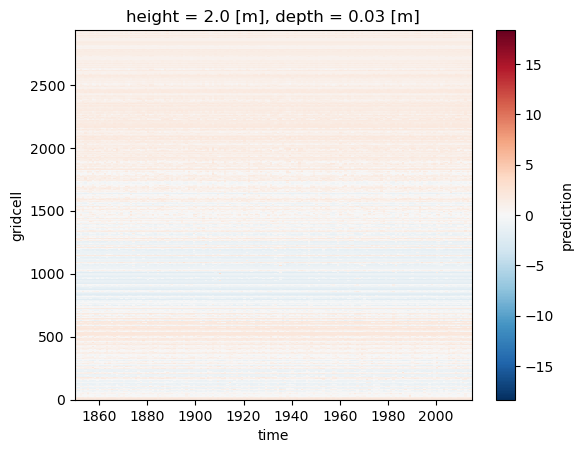

In [24]:
predictions_mean.isel(depth = 0).prediction.plot()

### Load Test Target

In [25]:
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=5)

In [26]:
test_target_unstacked = raw_mrsol_for_test.sel(time=slice(start, end)).resample(time="ME").mean()
test_target_unstacked = test_target_unstacked.sel(time= test_target_unstacked.time.dt.month == Month_idx).isel(depth=slice(0, max_depth))

test_target,_,_ = mask_stack_target(test_target_unstacked)

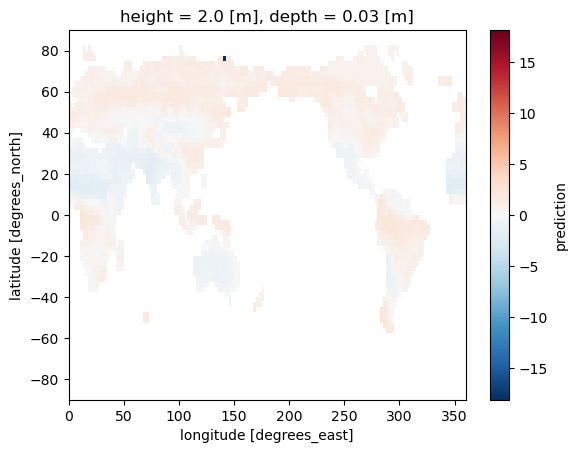

In [27]:
mesmer.grid.unstack_lat_lon_and_align(predictions_mean,test_target_unstacked).mean("time").isel(depth = 0).prediction.plot()

### Score

In [28]:
mask_max_da = model.mask.mask_mask(approx_maximas,chunk_mask).isel(depth=slice(0, max_depth))
stack_max_da = mesmer.grid.stack_lat_lon(mask_max_da).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol

In [29]:
#test_target

In [30]:
score = model_analysis.crps_score.crps_norm_score(predictions_mean,predictions_variance, test_target, transformation = "Logit", maximas_da = stack_max_da,ensemble_size = 15)

In [31]:
#test_target

In [32]:
const_mean_score = model_analysis.crps_score.crps_norm_score(test_target.mean("time").broadcast_like(test_target).transpose("gridcell","time","depth").rename_vars({"mrsol":"prediction"}),xr.zeros_like(predictions_variance), test_target, transformation = None, maximas_da = stack_max_da,ensemble_size = 15)


In [33]:
broadcast = test_target.mean("time")\
.broadcast_like(test_target)\
.transpose("gridcell","time","depth")

In [34]:
#test_target.isel(gridcell = 500 ).isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

In [35]:
#broadcast.isel(gridcell = 500 ).isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

In [36]:
mean_regr_score = model_analysis.crps_score.crps_norm_score(predictions_mean,xr.zeros_like(predictions_variance), test_target, transformation = "Logit", maximas_da = stack_max_da,ensemble_size = 15)

In [37]:
score_keys = ["model","mean_regr","const_mean"]

In [38]:
all_scores = xr.Dataset({"model":score.crps_score,"mean_regr":mean_regr_score.crps_score,"const_mean":const_mean_score.crps_score})

In [39]:
all_scores = mesmer.grid.unstack_lat_lon_and_align(all_scores, test_target_unstacked)

In [40]:
table = all_scores.mean(dim=["lon","lat","time"]).to_pandas().T
latex = table.to_latex(
     float_format="%.3f",
     caption="mean CRPS REF vs mean_regr vs const",
     label="tab:crpss"
)
latex

'\\begin{table}\n\\caption{mean CRPS REF vs mean_regr vs const}\n\\label{tab:crpss}\n\\begin{tabular}{lrrr}\n\\toprule\ndepth & 0.030000 & 0.190000 & 0.780000 \\\\\n\\midrule\nmodel & 0.420 & 1.648 & 6.697 \\\\\nmean_regr & 0.552 & 2.167 & 8.786 \\\\\nconst_mean & 0.981 & 2.770 & 9.834 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [41]:
all_scores.mean(dim=["lon","lat","time"])

<xarray.Dataset> Size: 96B
Dimensions:     (depth: 3)
Coordinates:
  * depth       (depth) float64 24B 0.03 0.19 0.78
Data variables:
    model       (depth) float64 24B 0.4203 1.648 6.697
    mean_regr   (depth) float64 24B 0.5523 2.167 8.786
    const_mean  (depth) float64 24B 0.9809 2.77 9.834

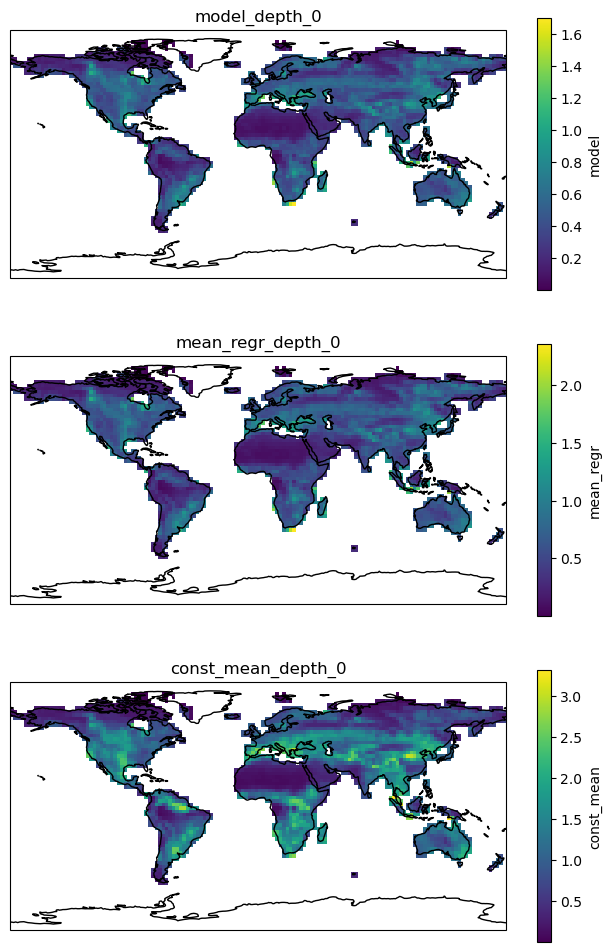

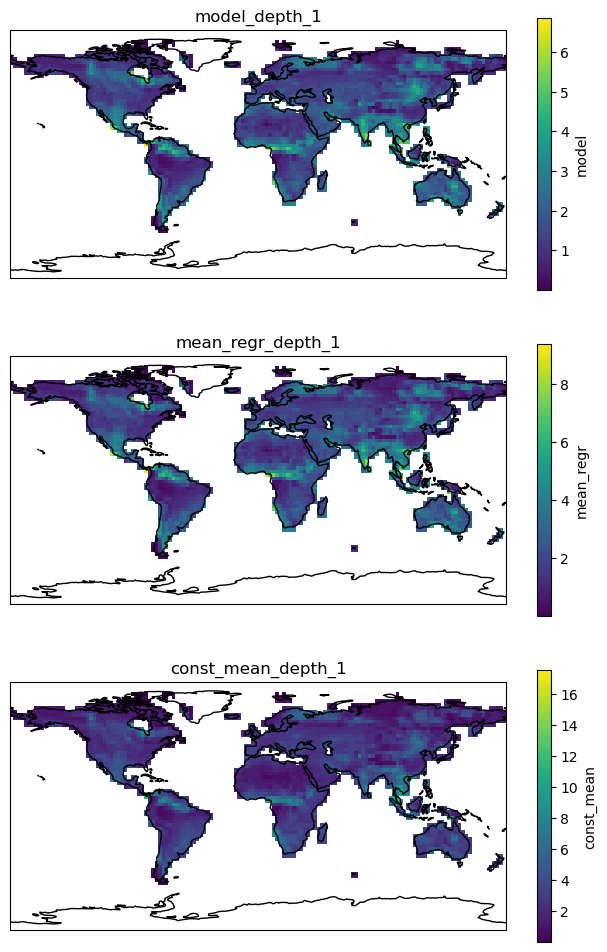

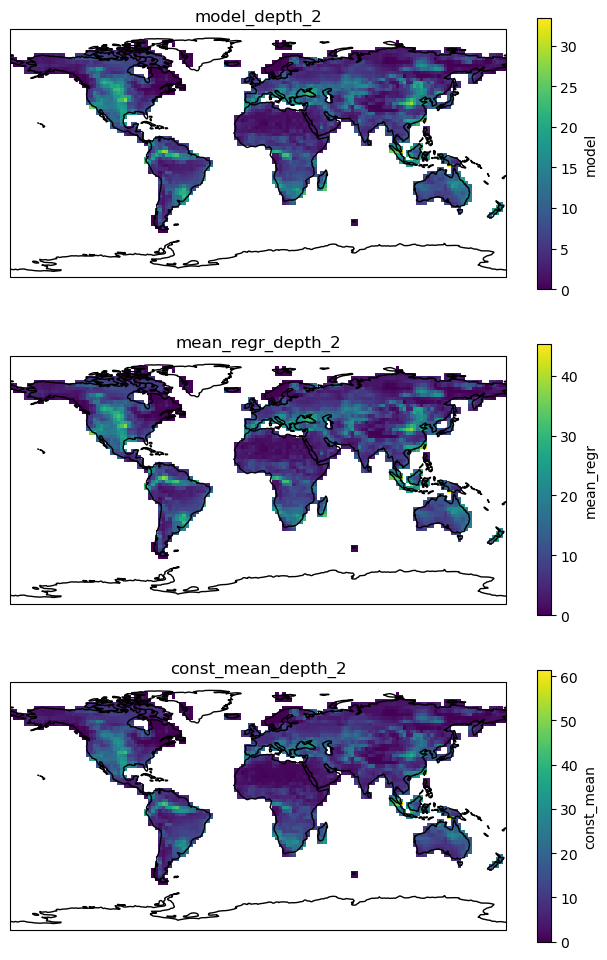

In [42]:
for depth in range(3):
    fig_global_crpss, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        nrows=3,
        ncols=1,
        figsize=(8, 12)
    )


    for i, s_key in enumerate(score_keys):
        da = all_scores.isel(depth=depth).mean("time")[s_key]
        da.plot(ax=ax[i])
        ax[i].coastlines()
        ax[i].set_title(f"{s_key}_depth_{depth}")

    fig_global_crpss.show()
    if safe:
        model.save.save_plot(fig_global_crpss, var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/ReferenceModel/AbsScore/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end},depth{depth}")
    

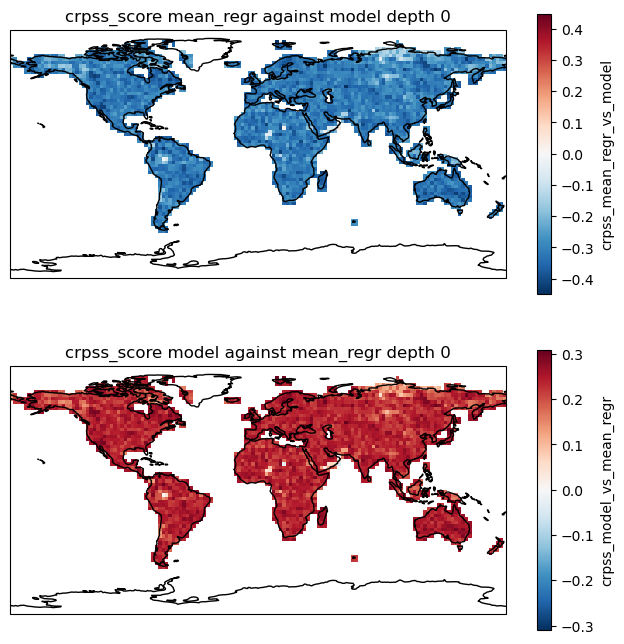

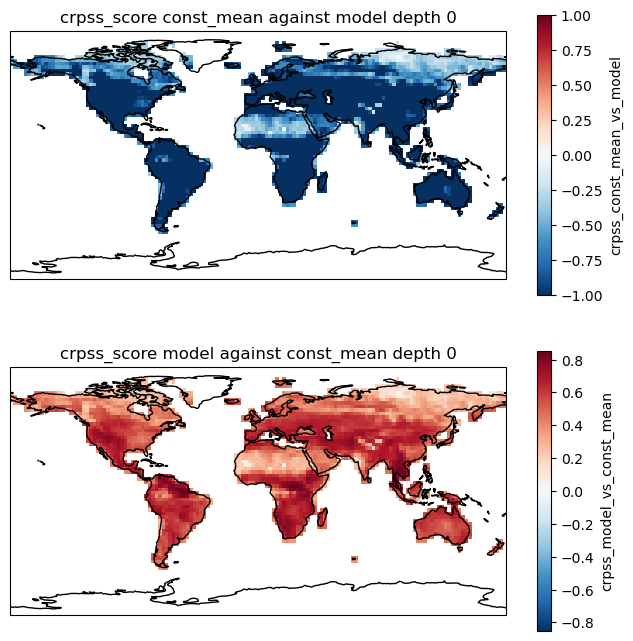

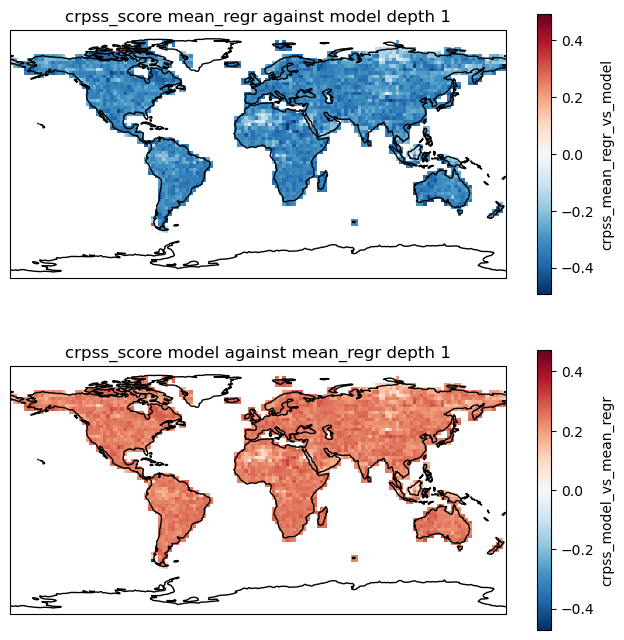

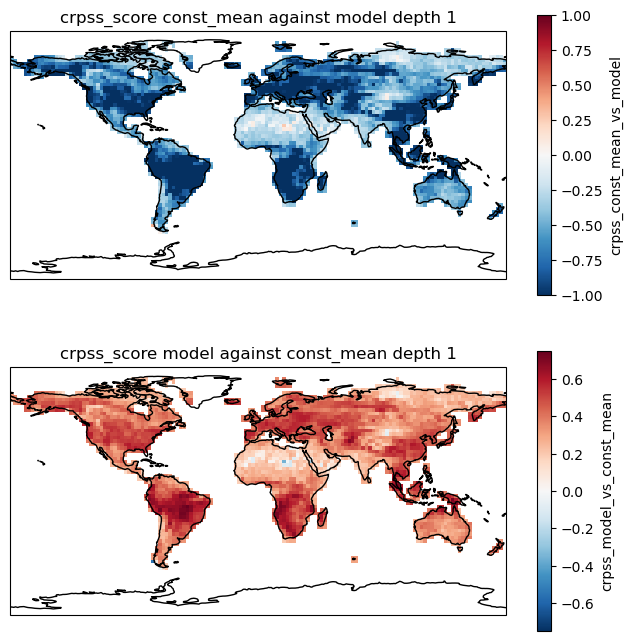

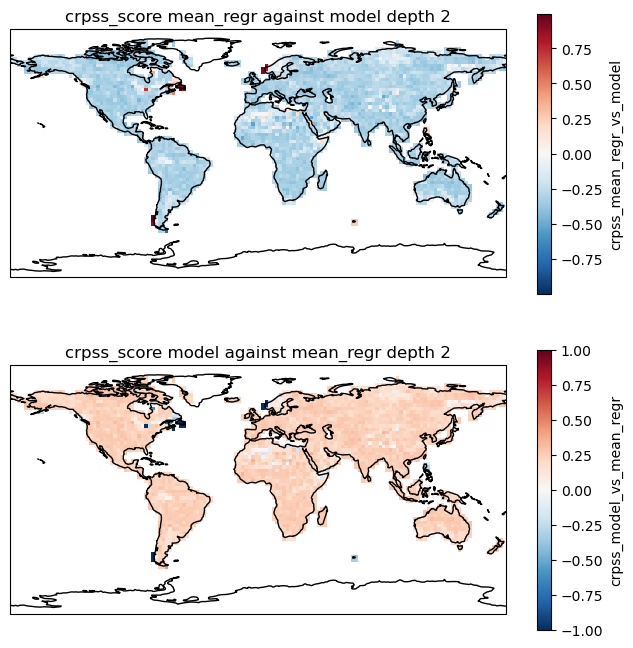

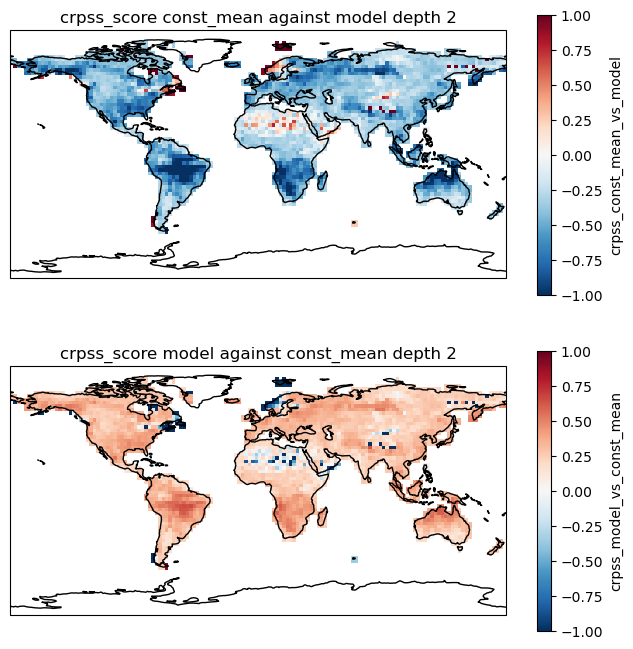

In [43]:

for depth in range(3):

    choice = "model"

    for i, s_key in enumerate(score_keys):
        if s_key == choice:
            continue
        vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(all_scores[choice],all_scores[s_key],choice,s_key)

        fig_global_crpss, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        nrows=2,
        ncols=1,
        figsize=(8, 8)
        )

        da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_{choice}"].clip(min=-1)
        da.plot(ax=ax[0])
        ax[0].coastlines()
        ax[0].set_title(f"crpss_score {s_key} against {choice} depth {depth}")

        da = vs.isel(depth=depth)[f"crpss_{choice}_vs_{s_key}"].clip(min=-1)
        da.plot(ax=ax[1])
        ax[1].coastlines()
        ax[1].set_title(f"crpss_score {choice} against {s_key} depth {depth}")

        fig_global_crpss.show()
        if safe:
            model.save.save_plot(fig_global_crpss, var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/ReferenceModel/{s_key}_against_{choice}/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end},depth{depth}")
        
    


In [44]:
all_predictions = xr.Dataset({"mean_pred":predictions_mean.prediction,"target":test_target.mrsol}) #"var_pred":predictions_variance.prediction, excludet
all_predictions = mesmer.grid.unstack_lat_lon_and_align(all_predictions, test_target_unstacked)
all_predictions["mean_pred"] = model.transform.Logit_Transform_ds_inv(all_predictions["mean_pred"]).mrsol * approx_maximas.mrsol

In [45]:
lat_points = {
    "North_West_America": 40,
    "Amazon": -5,
    "Europe": 50,
    "Sahara": 20,
    "South_Africa": -26,
    "South_Asia": 20,
    "East_Asia": 35,
    "Australia": -25,
}

lon_points = {
    "North_West_America": 245,    # -120°
    "Amazon": 300,        # -60°
    "Europe": 10,
    "Sahara": 12,
    "South_Africa": 25,
    "South_Asia": 78,
    "East_Asia": 115,
    "Australia": 135,
}

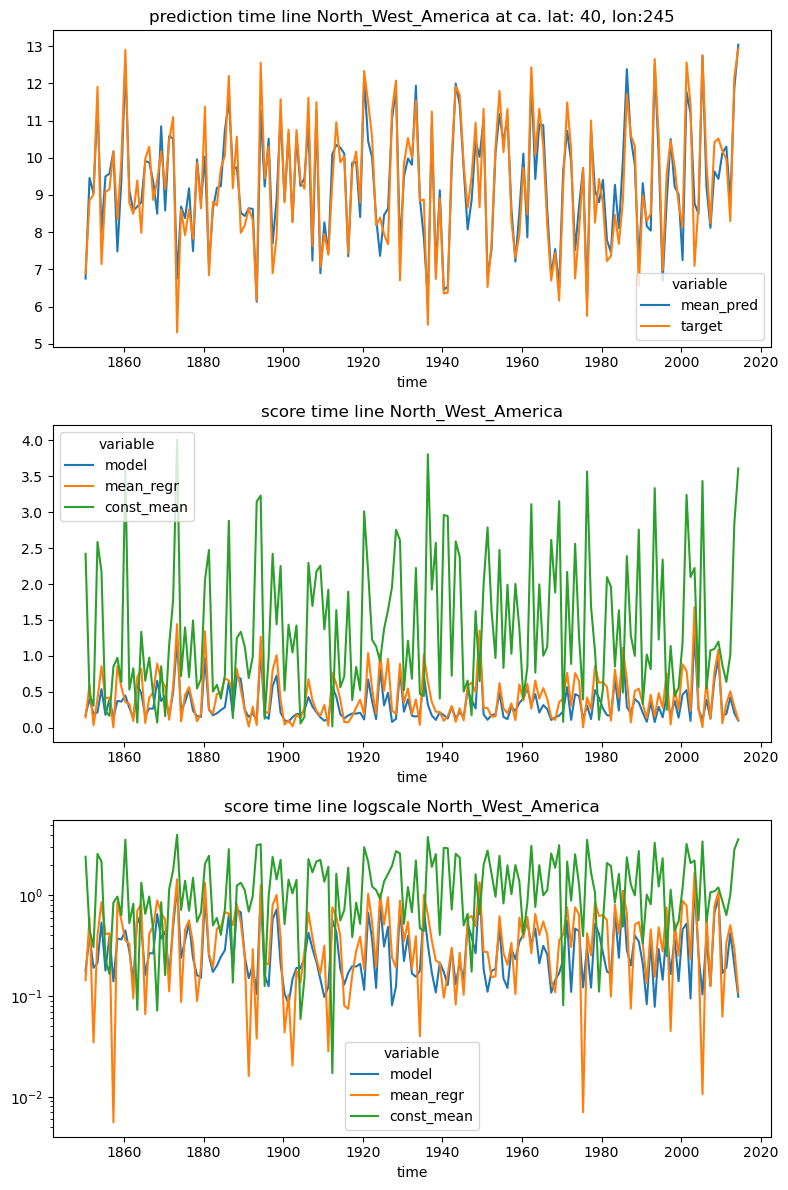

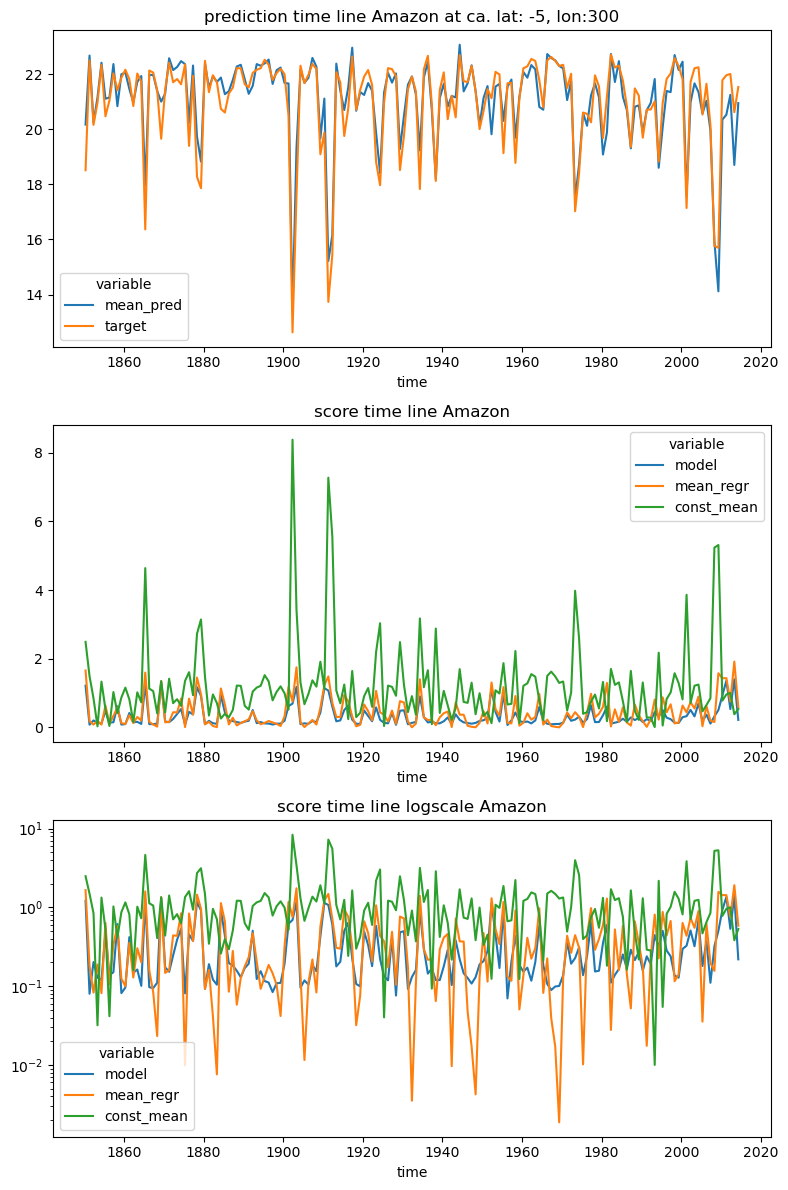

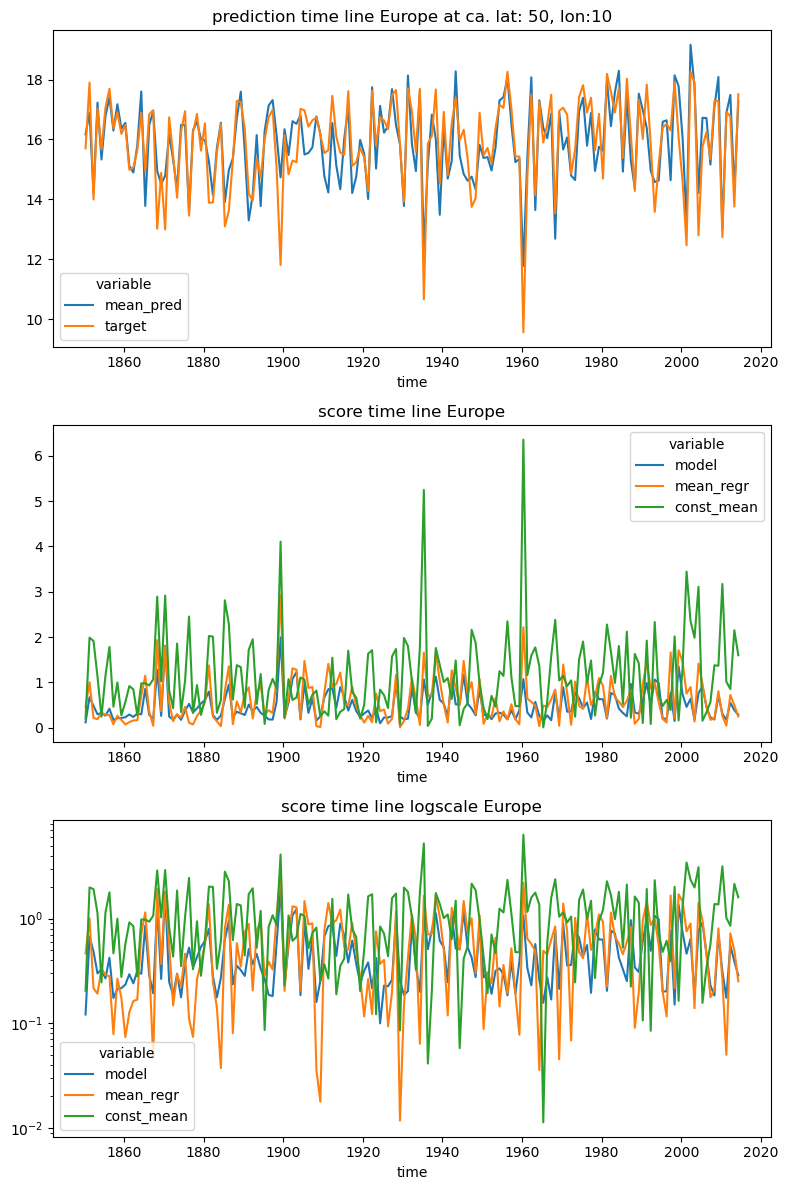

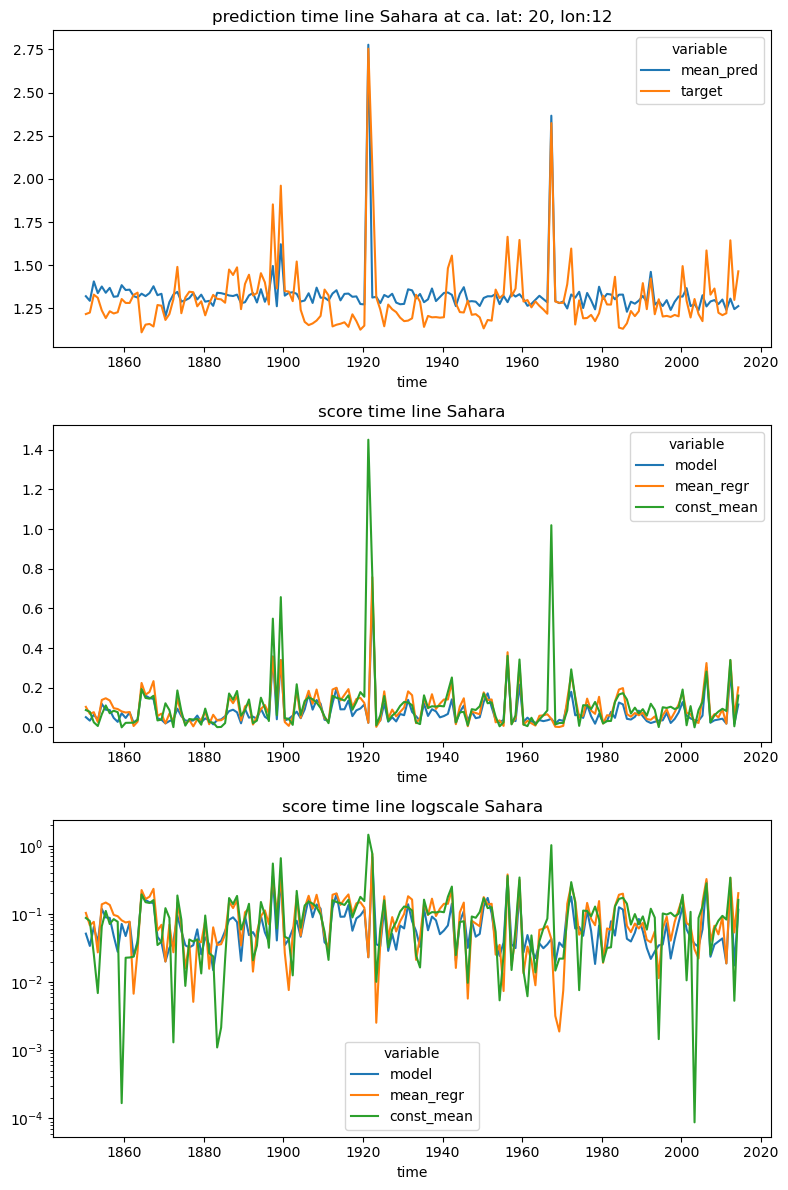

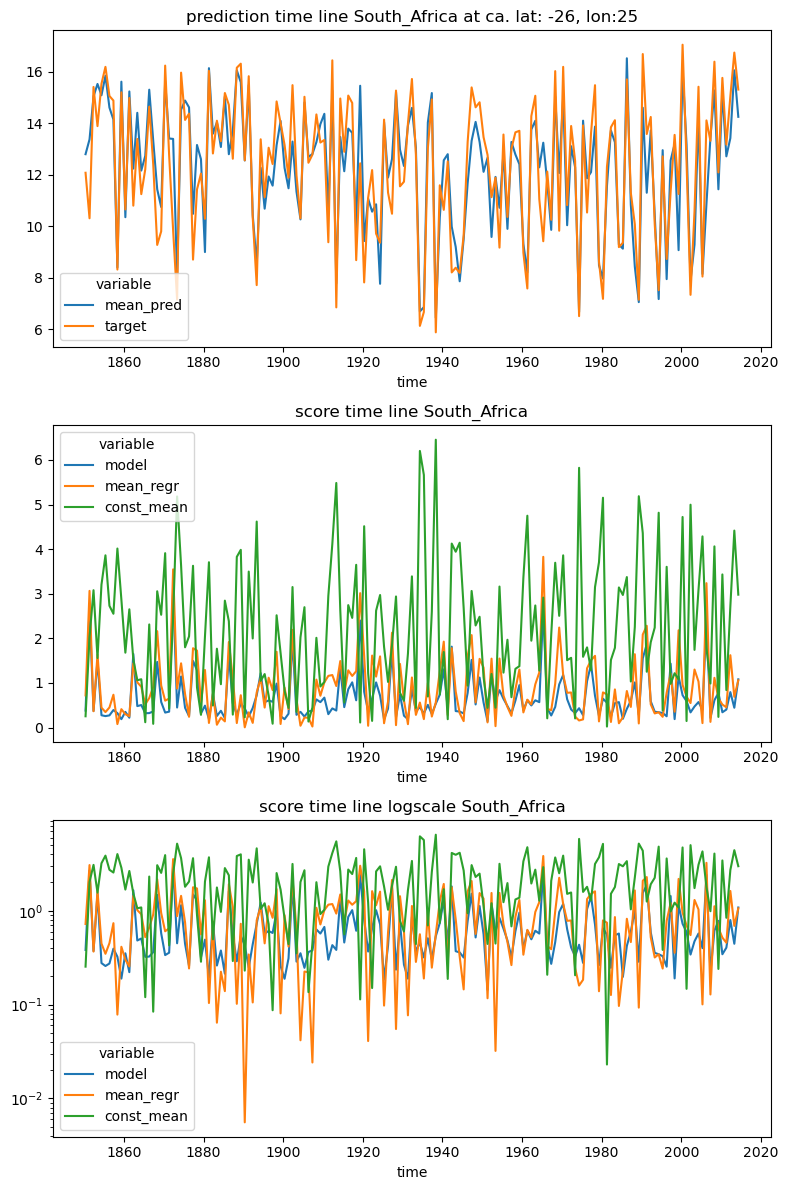

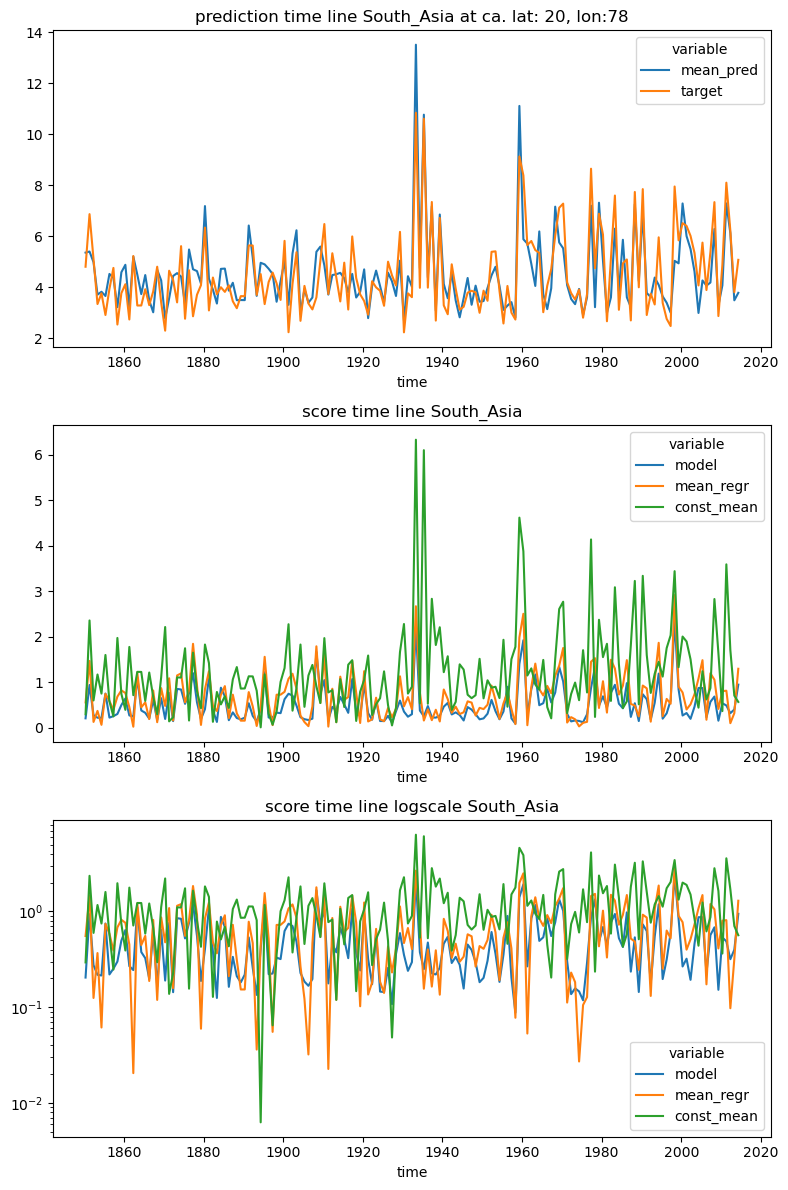

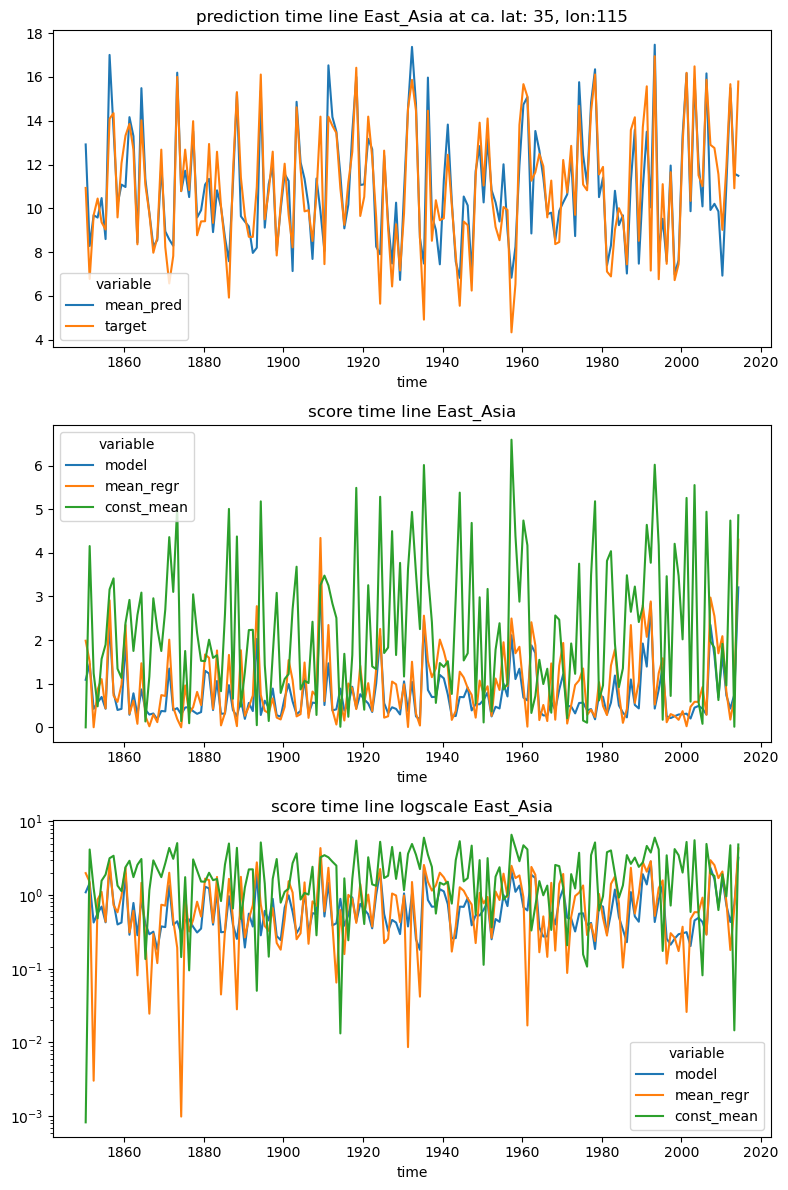

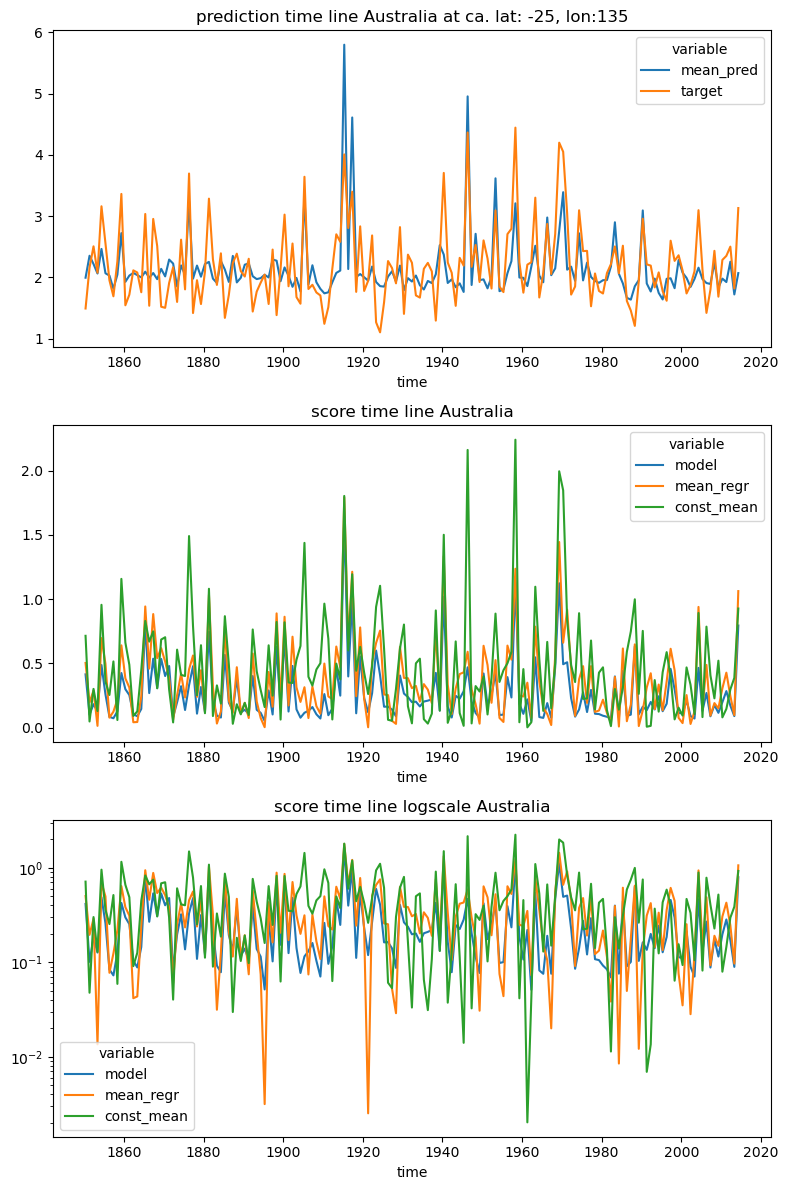

In [46]:
depth = 0
for pos_key in lat_points:
    
    fig_timeline, ax = plt.subplots(
            nrows=3,
            ncols=1,
            figsize=(8, 12)
            )

    all_predictions.sel(lat= lat_points[pos_key], lon = lon_points[pos_key], method="nearest").isel(depth = depth).to_array().plot.line(ax = ax[0],hue="variable", x = "time");
    ax[0].set_title(f"prediction time line {pos_key} at ca. lat: {lat_points[pos_key]}, lon:{lon_points[pos_key]}")

    all_scores.sel(lat= lat_points[pos_key], lon = lon_points[pos_key], method="nearest").isel(depth = depth).to_array().plot.line(ax = ax[1],hue="variable", x = "time");
    ax[1].set_title(f"score time line {pos_key}")
    
    all_scores.sel(lat= lat_points[pos_key], lon = lon_points[pos_key], method="nearest").isel(depth = depth).to_array().plot.line(ax = ax[2],hue="variable", x = "time");
    ax[2].set_title(f"score time line logscale {pos_key}")
    ax[2].set_yscale("log")

    fig_timeline.tight_layout()
    fig_timeline.show()
    if safe:
        model.save.save_plot(fig_timeline, var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/ReferenceModel/time_lines/{pos_key}/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end},depth{depth}")
            
